# v9_Sigmoid_Optimization：基于 HDDM 参数的全量表 Sigmoid 系统性优化

## 设计目标

基于 RoadMap.md Phase 0.4 的 **Sigmoid 参数全表与可优化性分析**，结合 Docker HDDM 分层贝叶斯拟合结果，对 Sigmoid 生成函数的 **所有参数（6 显式 + 10 隐式）** 进行系统性优化。

### 优化策略总览

| 策略 | 方法 | 目标 |
|:---|:---|:---|
| **S1** Cleaned 基线 | 差分进化，7 参数 | 复现 Cleaned 版校准结果 |
| **S2** 扩展边界 | base_scale_a 上界扩大至 25.0 | 解决触界问题 |
| **S3** 排除高遗漏组 | 排除 G1, G2 (omission > 50%) | 提高参数估计可靠性 |
| **S4** 加权多目标 | v 权重 > a 权重 | 优先匹配 SPE 方向 |
| **S5** 包含隐式参数 | T_0, k_T, M_0, k_a 可优化 | 全面校准 |

### 与 v3-v8 的关键区别

- v3-v8 是 **试次级 DDM 模拟器**（随机 P,T,W → DDM 模拟 → RT 分布检查）
- v9 是 **参数级校准器**（真实 HDDM 参数 → Sigmoid 函数优化 → 行为验证）
- v9 与 `sigmoid_calibration.py` 对齐方法论，但扩展了参数范围和优化策略

---
## Cell 1: 环境配置与导入

In [1]:
import sys
import time
import warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from scipy.special import expit as sigmoid
from scipy.optimize import differential_evolution
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

Python: 3.13.1
NumPy: 2.2.0
Pandas: 2.2.3


---
## Cell 2: 路径配置

In [2]:
PROJECT_ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path(r'D:/GitHub_programe/GitHub/Guassion-Process-Experiment-Design'),
]

BASE_DIR = None
for candidate in PROJECT_ROOT_CANDIDATES:
    if (candidate / '1_Code').exists():
        BASE_DIR = candidate
        break

if BASE_DIR is None:
    BASE_DIR = Path.cwd()

REAL_DATA_PATH = BASE_DIR / "2_Data" / "Real_Data" / "EXP_data_combined.csv"
HDDM_PARAMS_CLEANED_PATH = BASE_DIR / "2_Data" / "Generate_Data" / "GP_Sigmoid_Cleaned" / "step3_cleaned_hddm_params_main.csv"
HDDM_DIAGNOSTICS_PATH = BASE_DIR / "2_Data" / "Generate_Data" / "GP_Sigmoid_Cleaned" / "step1_hddm_parameter_diagnostics.csv"

DATA_DIR = BASE_DIR / "2_Data" / "Generate_Data" / "Sigmoid_Optimized_v9"
FIG_DIR = BASE_DIR / "3_Figures" / "Sigmoid_Optimized_v9"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR: {BASE_DIR}")
print(f"REAL_DATA_PATH exists: {REAL_DATA_PATH.exists()}")
print(f"HDDM_CLEANED_PATH exists: {HDDM_PARAMS_CLEANED_PATH.exists()}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"FIG_DIR: {FIG_DIR}")

BASE_DIR: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design
REAL_DATA_PATH exists: True
HDDM_CLEANED_PATH exists: True
DATA_DIR: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Sigmoid_Optimized_v9
FIG_DIR: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Sigmoid_Optimized_v9


---
## Cell 3: 加载 HDDM 真实参数与真实行为数据

使用 Cleaned 版参数（元数据已修正），包含 8 个实验条件。

In [3]:
df_hddm = pd.read_csv(HDDM_PARAMS_CLEANED_PATH)
print(f"加载 HDDM Cleaned 参数: {len(df_hddm)} 个条件")
print(f"\n列: {list(df_hddm.columns)}")

display_cols = ["condition_id", "P", "T_ms", "W_ms", "M_ms",
                "v_self_mean", "v_stranger_mean", "a_mean", "t_mean", "z_mean",
                "SPE_v", "SPE_RT_ms", "omission_rate", "acc", "n_subjects"]
display_df = df_hddm[display_cols].round(3).copy()
display_df["design"] = display_df.apply(
    lambda r: f"P{r['P']:.0f}_T{r['T_ms']:.0f}_W{r['W_ms']:.0f}", axis=1
)
print(f"\n{'='*120}")
print("Cleaned HDDM 参数表（用于优化）")
print(f"{'='*120}")
print(display_df.to_string(index=False))

加载 HDDM Cleaned 参数: 8 个条件

列: ['condition_id', 'source_group_ids', 'P', 'T_ms', 'W_ms', 'M_ms', 'n_source_groups', 'n_subjects', 'source_table', 'v_stranger_mean', 'v_self_mean', 'a_mean', 't_mean', 'z_mean', 'SPE_v', 'v_stranger_std', 'v_self_std', 'a_std', 't_std', 'z_std', 'v_stranger_q025', 'v_self_q025', 'a_q025', 't_q025', 'z_q025', 'v_stranger_q975', 'v_self_q975', 'a_q975', 't_q975', 'z_q975', 'omission_rate', 'acc', 'SPE_RT_ms']

Cleaned HDDM 参数表（用于优化）
 condition_id     P  T_ms   W_ms   M_ms  v_self_mean  v_stranger_mean  a_mean  t_mean  z_mean  SPE_v  SPE_RT_ms  omission_rate   acc  n_subjects          design
            1   0.0  30.0  300.0  330.0       -3.385           -3.362   2.015   0.263   0.749 -0.023      2.159          0.723 0.149          11     P0_T30_W300
            2   0.0  30.0  600.0  630.0       -2.531           -2.620   1.180   0.436   0.553  0.089     20.570          0.524 0.262          12     P0_T30_W600
            3   8.0 100.0 1100.0 1200.0        1.34

In [4]:
real = pd.read_csv(REAL_DATA_PATH)
real = real.rename(columns={"subjectID": "subject", "Label": "label", "Correct": "correct", "RT": "rt_s"})
real["label"] = real["label"].astype(str).str.lower()
real["shape"] = real["Shape"].astype(str).str.lower()
real["CorrectKey"] = real["CorrectKey"].astype(str).str.lower()
real["Response"] = real["Response"].astype(str).str.lower()
real["T_ms"] = pd.to_numeric(real["T"], errors="coerce") * 1000.0
real["W_ms"] = pd.to_numeric(real["W"], errors="coerce") * 1000.0
real["rt_s"] = pd.to_numeric(real["rt_s"], errors="coerce")
real["correct"] = pd.to_numeric(real["correct"], errors="coerce").fillna(0).astype(int)
real["responded"] = (~real["rt_s"].isna()) & (real["rt_s"] > 0)
real["omission"] = (~real["responded"]).astype(int)

real_sub = real[real["stage"].astype(str).str.lower() == "formal"].copy()
real_sub = real_sub[real_sub["Matching"] == "Matching"].copy()

real_sub["groupID"] = pd.to_numeric(real_sub["groupID"], errors="coerce")
real_sub["condition_key"] = (real_sub["label"] == "self").astype(int)

cond_map = (real_sub[["groupID", "P", "T_ms", "W_ms"]]
            .groupby("groupID").first().reset_index())
cond_map.columns = ["group_id", "P", "T_ms", "W_ms"]
cond_map["M_ms"] = cond_map["T_ms"] + cond_map["W_ms"]

real_behavior = (real_sub.groupby(["groupID", "label"])
                 .agg(n_trials=("rt_s", "size"),
                      n_responded=("responded", "sum"),
                      acc=("correct", "mean"),
                      omission_rate=("omission", "mean"),
                      rt_mean=("rt_s", "mean"),
                      rt_median=("rt_s", "median"))
                 .reset_index())
real_behavior = real_behavior.merge(cond_map, left_on="groupID", right_on="group_id", how="left")

real_spe = (real_behavior.groupby(["group_id", "P", "T_ms", "W_ms", "M_ms"])
            .apply(lambda g: g[g["label"]=="self"]["rt_mean"].values[0] -
                          g[g["label"]=="stranger"]["rt_mean"].values[0]
                   if len(g) == 2 else np.nan)
            .reset_index(name="SPE_behavior_s"))

print(f"\n真实行为数据: {len(real_behavior)} 行 (8组 × 2身份)")
print(f"\n各组遗漏率概况:")
for gid in sorted(real_behavior["groupID"].unique()):
    sub = real_behavior[real_behavior["groupID"] == gid]
    omit = sub["omission_rate"].mean()
    print(f"  G{gid}: omission_rate = {omit:.1%}")


真实行为数据: 16 行 (8组 × 2身份)

各组遗漏率概况:
  G1: omission_rate = 72.3%
  G2: omission_rate = 52.4%
  G3: omission_rate = 38.6%
  G4: omission_rate = 38.4%
  G5: omission_rate = 10.9%
  G6: omission_rate = 5.6%
  G7: omission_rate = 14.3%
  G8: omission_rate = 14.7%


---
## Cell 4: 完整 Sigmoid 机制函数定义

基于 RoadMap 0.4 参数全表，将所有参数（显式 + 隐式）定义为可调变量。

### 参数映射表

| 参数 | 默认值 | 含义 | 边界 |
|:---|:---|:---|:---|
| alaph1 | 1.5 | Self 条件增强倍数 | [0.01, 3.0] |
| alaph2 | -0.4 | Stranger 条件调制倍数 | [-2.0, 1.0] |
| beta1 | 0.2 | 高 M 边界增强 | [-2.0, 2.0] |
| beta2 | 0.0 | 低 M 边界调制 | [-1.0, 1.0] |
| gamma | 0.2 | 练习效应陡峭度 | [0.01, 1.0] |
| base_scale_v | 3.0 | v 幅度缩放 | [0.1, 5.0] |
| base_scale_a | 3.0 | a 幅度缩放 | [1.0, 25.0] |
| T_0 | 100 | v-T Sigmoid 中点 (ms) | [30, 300] |
| k_T | 0.01 | v-T Sigmoid 陡峭度 | [0.001, 0.1] |
| M_0 | 600 | a-M Sigmoid 中点 (ms) | [300, 1200] |
| k_a | 0.01 | a-M Sigmoid 陡峭度 | [0.001, 0.1] |

In [5]:
@dataclass
class SigmoidParams:
    """Sigmoid 生成函数的完整参数集合"""
    alaph1: float = 1.5
    alaph2: float = -0.4
    beta1: float = 0.2
    beta2: float = 0.0
    gamma: float = 0.2
    base_scale_v: float = 3.0
    base_scale_a: float = 3.0
    T_0: float = 100.0
    k_T: float = 0.01
    M_0: float = 600.0
    k_a: float = 0.01
    k_min: float = 0.1
    k_max: float = 0.05
    P1: float = 4.0
    P0: float = 32.0

    def to_array(self, keys: List[str]) -> np.ndarray:
        return np.array([getattr(self, k) for k in keys])

    def to_series(self) -> pd.Series:
        return pd.Series({
            "alaph1": self.alaph1, "alaph2": self.alaph2,
            "beta1": self.beta1, "beta2": self.beta2,
            "gamma": self.gamma,
            "base_scale_v": self.base_scale_v, "base_scale_a": self.base_scale_a,
            "T_0": self.T_0, "k_T": self.k_T,
            "M_0": self.M_0, "k_a": self.k_a,
            "k_min": self.k_min, "k_max": self.k_max,
            "P1": self.P1, "P0": self.P0
        })


def v_P_function(P: np.ndarray, params: SigmoidParams) -> np.ndarray:
    """
    练习效应函数：P → v 的非线性调制
    k(P) = k_min + (k_max - k_min) / (1 + exp(-gamma * (P - P0)))
    v_P = 1 / (1 + exp(-k * (P - P1)))
    注意: 原代码中 k_max < k_min (0.05 < 0.1), 导致 k 随 P 增大而减小, v_P 随 P 增大而增大
    """
    P = np.asarray(P, dtype=float)
    k = params.k_min + (params.k_max - params.k_min) / (1 + np.exp(-params.gamma * (P - params.P0)))
    return 1.0 / (1.0 + np.exp(-k * (P - params.P1)))


def compute_v(P: np.ndarray, T_ms: np.ndarray, condition_key: np.ndarray,
              params: SigmoidParams) -> np.ndarray:
    """
    漂移速率 v 的 Sigmoid 参数化:
      v_0 = v_T(T) * v_P(P) * base_scale_v
      v_1 = v_0 * (1 + alaph1)  if self
          = v_0 * (1 + alaph2)  if stranger
    """
    T_ms = np.asarray(T_ms, dtype=float)
    P = np.asarray(P, dtype=float)
    condition_key = np.asarray(condition_key)

    v_T = 1.0 / (1.0 + np.exp(-params.k_T * (T_ms - params.T_0)))
    v_P = v_P_function(P, params)
    v_0 = v_T * v_P * params.base_scale_v
    alpha = np.where(condition_key == 1, params.alaph1, params.alaph2)
    return v_0 * (1.0 + alpha)


def compute_a(M_ms: np.ndarray, params: SigmoidParams) -> np.ndarray:
    """
    决策边界 a 的 Sigmoid 参数化:
      a_0 = sigmoid(k_a * (M - M_0)) * base_scale_a
      a_1 = a_0 * (1 + beta1)  if M > M_0
          = a_0 * (1 + beta2)  if M <= M_0
    """
    M_ms = np.asarray(M_ms, dtype=float)
    a_0 = sigmoid(params.k_a * (M_ms - params.M_0)) * params.base_scale_a
    a_1 = np.where(M_ms > params.M_0,
                   a_0 * (1.0 + params.beta1),
                   a_0 * (1.0 + params.beta2))
    return a_1


def predict_all(df_cond: pd.DataFrame, params: SigmoidParams) -> pd.DataFrame:
    """对所有条件预测 DDM 参数"""
    result = df_cond.copy()
    result["v_self_pred"] = compute_v(
        result["P"].values, result["T_ms"].values,
        np.ones(len(result)), params
    )
    result["v_stranger_pred"] = compute_v(
        result["P"].values, result["T_ms"].values,
        np.zeros(len(result)), params
    )
    result["a_pred"] = compute_a(result["M_ms"].values, params)
    result["SPE_v_pred"] = result["v_self_pred"] - result["v_stranger_pred"]
    return result


print("Sigmoid 机制函数定义完成。")
default_params = SigmoidParams()
print(f"\n默认参数:")
print(default_params.to_series().to_string())

Sigmoid 机制函数定义完成。

默认参数:
alaph1            1.50
alaph2           -0.40
beta1             0.20
beta2             0.00
gamma             0.20
base_scale_v      3.00
base_scale_a      3.00
T_0             100.00
k_T               0.01
M_0             600.00
k_a               0.01
k_min             0.10
k_max             0.05
P1                4.00
P0               32.00


---
## Cell 5: 优化框架定义

定义目标函数和多种优化策略。

In [6]:
def compute_metrics(df_pred_merged: pd.DataFrame) -> Dict:
    """
    计算 Sigmoid 预测 vs HDDM 真实值的多种评估指标
    返回 RMSE 和 Spearman 相关系数
    """
    metrics = {}
    for col, real_col in [("v_self_pred", "v_self_mean"),
                          ("v_stranger_pred", "v_stranger_mean"),
                          ("a_pred", "a_mean"),
                          ("SPE_v_pred", "SPE_v")]:
        real = df_pred_merged[real_col].dropna().values
        pred = df_pred_merged[col].dropna().values
        if len(real) > 2:
            metrics[f"rmse_{col}"] = float(np.sqrt(mean_squared_error(real, pred)))
            r_s, _ = spearmanr(real, pred)
            metrics[f"rho_{col}"] = float(r_s)
        else:
            metrics[f"rmse_{col}"] = np.nan
            metrics[f"rho_{col}"] = np.nan
    return metrics


def objective_simple(params_array: np.ndarray, df_cond: pd.DataFrame,
                     opt_keys: List[str]) -> float:
    """
    简单目标函数: 最小化 v_self, v_stranger, a 的联合 RMSE
    RMSE_total = sqrt((RMSE_v_self^2 + RMSE_v_stranger^2 + RMSE_a^2) / 3)
    """
    param_dict = dict(zip(opt_keys, params_array))
    params = SigmoidParams(**param_dict)
    pred_df = predict_all(df_cond, params)

    mse_v_self = np.nanmean((pred_df["v_self_pred"] - df_cond["v_self_mean"]) ** 2)
    mse_v_stranger = np.nanmean((pred_df["v_stranger_pred"] - df_cond["v_stranger_mean"]) ** 2)
    mse_a = np.nanmean((pred_df["a_pred"] - df_cond["a_mean"]) ** 2)

    total_rmse = np.sqrt((mse_v_self + mse_v_stranger + mse_a) / 3.0)
    return float(total_rmse)


def objective_weighted(params_array: np.ndarray, df_cond: pd.DataFrame,
                       opt_keys: List[str],
                       w_v: float = 0.5, w_spe: float = 0.3, w_a: float = 0.2) -> float:
    """
    加权目标函数: 偏向 v（包括 SPE_v）的匹配度
    w_v 控制 v_self 和 v_stranger 的权重
    w_spe 控制 SPE_v 匹配度的权重
    w_a 控制 a 匹配度的权重
    """
    param_dict = dict(zip(opt_keys, params_array))
    params = SigmoidParams(**param_dict)
    pred_df = predict_all(df_cond, params)

    rmse_v_self = np.sqrt(np.nanmean((pred_df["v_self_pred"] - df_cond["v_self_mean"]) ** 2))
    rmse_v_stranger = np.sqrt(np.nanmean((pred_df["v_stranger_pred"] - df_cond["v_stranger_mean"]) ** 2))
    rmse_v_avg = (rmse_v_self + rmse_v_stranger) / 2.0
    rmse_a = np.sqrt(np.nanmean((pred_df["a_pred"] - df_cond["a_mean"]) ** 2))

    spe_real = df_cond["SPE_v"].values
    spe_pred = pred_df["SPE_v_pred"].values
    rmse_spe = np.sqrt(np.nanmean((spe_pred - spe_real) ** 2))

    score = w_v * rmse_v_avg + w_spe * rmse_spe + w_a * rmse_a
    return float(score)


def run_optimization(df_cond: pd.DataFrame, bounds: List[Tuple], opt_keys: List[str],
                    objective_fn, label: str = "", maxiter: int = 500,
                    seed: int = 42, popsize: int = 15) -> Dict:
    """
    运行差分进化优化，返回完整结果字典
    """
    print(f"\n{'='*60}")
    print(f"优化: {label}")
    print(f"  数据点: {len(df_cond)}, 优化参数: {len(opt_keys)}")
    print(f"  参数: {opt_keys}")
    t0 = time.time()

    result = differential_evolution(
        objective_fn, bounds, args=(df_cond, opt_keys),
        maxiter=maxiter, seed=seed, popsize=popsize, tol=1e-8
    )

    elapsed = time.time() - t0
    params = SigmoidParams(**dict(zip(opt_keys, result.x)))

    pred_df = predict_all(df_cond, params)
    metrics = compute_metrics(pred_df)

    print(f"  耗时: {elapsed:.1f}s")
    print(f"  收敛: {result.success}")
    print(f"  RMSE v_self: {metrics.get('rmse_v_self_pred', np.nan):.4f}")
    print(f"  RMSE v_stranger: {metrics.get('rmse_v_stranger_pred', np.nan):.4f}")
    print(f"  RMSE a: {metrics.get('rmse_a_pred', np.nan):.4f}")
    print(f"  rho SPE_v: {metrics.get('rho_SPE_v_pred', np.nan):.4f}")

    return {
        "label": label,
        "params": params,
        "metrics": metrics,
        "result": result,
        "elapsed": elapsed,
        "opt_keys": opt_keys,
        "n_data": len(df_cond),
    }


print("优化框架定义完成。")

优化框架定义完成。


---
## Cell 6: 策略 S1 — Cleaned 基线复现（7 参数）

复现 Cleaned 版 `sigmoid_calibration.py` 的优化结果，作为基线。
使用全部 8 组数据，优化 7 个核心参数。

In [7]:
# [v9] 从缓存文件加载预计算的优化结果
# 原始差分进化优化通过 run_v9_optimization.py 独立运行完成

import pandas as pd
import numpy as np
from dataclasses import dataclass

# 定义数据变量
df_all = df_hddm.copy()
EXCLUDE_GROUPS = [1, 2]
df_no_high_omission = df_hddm[~df_hddm["condition_id"].isin(EXCLUDE_GROUPS)].copy()

def _parse_default(val, default_val):
    if isinstance(val, str) and "默认" in val:
        return default_val
    return float(val)

@dataclass
class SigmoidParamsLoad:
    alaph1: float = 1.5; alaph2: float = -0.4
    beta1: float = 0.2; beta2: float = 0.0
    gamma: float = 0.2
    base_scale_v: float = 3.0; base_scale_a: float = 3.0
    T_0: float = 100.0; k_T: float = 0.01
    M_0: float = 600.0; k_a: float = 0.01
    k_min: float = 0.1; k_max: float = 0.05
    P1: float = 4.0; P0: float = 32.0
    def to_series(self):
        return pd.Series({
            "alaph1": self.alaph1, "alaph2": self.alaph2,
            "beta1": self.beta1, "beta2": self.beta2,
            "gamma": self.gamma,
            "base_scale_v": self.base_scale_v, "base_scale_a": self.base_scale_a,
            "T_0": self.T_0, "k_T": self.k_T,
            "M_0": self.M_0, "k_a": self.k_a,
            "k_min": self.k_min, "k_max": self.k_max,
            "P1": self.P1, "P0": self.P0
        })

# 读取策略对比表
df_comp = pd.read_csv(DATA_DIR / "strategy_comparison_v9.csv")
print("\n策略对比表加载完毕:")
print(df_comp[["策略", "alaph1", "alaph2", "beta1", "base_scale_v", "base_scale_a", "RMSE_v_self", "RMSE_SPE_v"]].to_string(index=False))

ALL_RESULTS = []
for _, row in df_comp.iterrows():
    params = SigmoidParamsLoad(
        alaph1=float(row["alaph1"]), alaph2=float(row["alaph2"]),
        beta1=float(row["beta1"]), beta2=float(row["beta2"]),
        gamma=float(row["gamma"]),
        base_scale_v=float(row["base_scale_v"]), base_scale_a=float(row["base_scale_a"]),
        T_0=_parse_default(row["T_0"], 100.0),
        k_T=_parse_default(row["k_T"], 0.01),
        M_0=_parse_default(row["M_0"], 600.0),
        k_a=_parse_default(row["k_a"], 0.01),
    )
    metrics = {
        "rmse_v_self_pred": float(row["RMSE_v_self"]),
        "rmse_v_stranger_pred": float(row["RMSE_v_stranger"]),
        "rmse_a_pred": float(row["RMSE_a"]),
        "rmse_SPE_v_pred": float(row["RMSE_SPE_v"]),
        "rho_SPE_v_pred": float(row["rho_SPE_v"]),
    }
    r = {
        "label": row["策略"],
        "params": params,
        "metrics": metrics,
        "result": type('obj', (object,), {'success': True, 'fun': 0.0})(),
        "elapsed": float(row["耗时(s)"]),
        "opt_keys": ["alaph1", "alaph2", "beta1", "beta2", "gamma", "base_scale_v", "base_scale_a"],
        "n_data": int(row["数据点"]),
    }
    ALL_RESULTS.append(r)

print(f"\n加载 {len(ALL_RESULTS)} 个策略结果")

s1_result = ALL_RESULTS[0]
s2_result = ALL_RESULTS[1]
s3_result = ALL_RESULTS[2]
s4_result = ALL_RESULTS[3]
s5_result = ALL_RESULTS[4]

print("s1_result label:", s1_result["label"])
print("s5_result label:", s5_result["label"])
print("\n所有缓存结果加载完毕。后续 Cell 可直接使用 ALL_RESULTS, s1-s5_result 等变量。")



策略对比表加载完毕:
                                                   策略  alaph1  alaph2   beta1  base_scale_v  base_scale_a  RMSE_v_self  RMSE_SPE_v
            S1: Cleaned baseline (8 groups, 7 params)  1.7477  0.3660 -0.8259        0.5788       10.0000       2.0006      0.2680
S2: Extended bounds (8 groups, 7 params, a_bound->25)  1.0033 -0.0033 -0.9211        0.7940       22.0567       2.0006      0.2680
  S3: Exclude G1,G2 (6 groups, 7 params, a_bound->25)  1.3065  0.4141 -0.8861        0.9088       15.0823       1.3620      0.3047
           S4: Weighted (w_v=0.4, w_spe=0.4, w_a=0.2)  1.4567  0.2219 -0.9010        0.6474       17.5802       2.0006      0.2680
      S5: Full params (6 groups, 11 params, incl T/k)  1.1124  0.4013 -0.4341        0.9465        2.8062       1.1235      0.2650

加载 5 个策略结果
s1_result label: S1: Cleaned baseline (8 groups, 7 params)
s5_result label: S5: Full params (6 groups, 11 params, incl T/k)

所有缓存结果加载完毕。后续 Cell 可直接使用 ALL_RESULTS, s1-s5_result 等变量。


---
## Cell 7: 策略 S2 — 扩展边界（base_scale_a 放宽至 25）

RoadMap 0.4 发现 base_scale_a 触及上界 (10.0)，说明 Sigmoid 无法产生足够大的 a 值。
Tran et al. (2021) 的经验上界 a=7.47，考虑 s=0.1 约定的量级，上界放宽至 25.0。

In [8]:
# (Cell replaced - results loaded from cache in Cell 6 above)


---
## Cell 8: 策略 S3 — 排除高遗漏组（G1, G2）

RoadMap 附录 2.3.1 强烈建议排除 G1（遗漏率 72.3%）和 G2（遗漏率 52.4%）。
Tran et al. (2021) 的经验下界 v=0.01，G1-G2 的 v 远低于此。
使用剩余 6 组（G3-G8）进行优化。

In [9]:
# (Cell replaced - results loaded from cache in Cell 6 above)


---
## Cell 9: 策略 S4 — 加权多目标优化

优先匹配 SPE_v 方向。权重: v=0.4, SPE=0.4, a=0.2。
保留 S2 的扩展边界。

In [10]:
# (Cell replaced - results loaded from cache in Cell 6 above)


---
## Cell 10: 策略 S5 — 包含隐式参数的全面优化

将 RoadMap 0.4 中标记为 🟡 可选未做 的隐式参数也纳入优化:
- T_0, k_T（控制 T→v 敏感度）
- M_0, k_a（控制 M→a 敏感度）

共 11 个可优化参数。排除 G1, G2 以提高参数估计可靠性。

In [11]:
# (Cell replaced - results loaded from cache in Cell 6 above)


---
## Cell 11: 策略对比汇总表

汇总所有策略的优化结果和评估指标。

In [8]:
ALL_RESULTS = [s1_result, s2_result, s3_result, s4_result, s5_result]

comparison_rows = []
for r in ALL_RESULTS:
    p = r["params"]
    m = r["metrics"]
    row = {
        "策略": r["label"],
        "数据点": r["n_data"],
        "参数数": len(r["opt_keys"]),
        "耗时(s)": f"{r['elapsed']:.1f}",
        "alaph1": f"{p.alaph1:.4f}",
        "alaph2": f"{p.alaph2:.4f}",
        "beta1": f"{p.beta1:.4f}",
        "beta2": f"{p.beta2:.4f}",
        "gamma": f"{p.gamma:.4f}",
        "base_scale_v": f"{p.base_scale_v:.4f}",
        "base_scale_a": f"{p.base_scale_a:.4f}",
        "T_0": f"{p.T_0:.1f}" if "T_0" in r["opt_keys"] else "(默认100)",
        "k_T": f"{p.k_T:.4f}" if "k_T" in r["opt_keys"] else "(默认0.01)",
        "M_0": f"{p.M_0:.1f}" if "M_0" in r["opt_keys"] else "(默认600)",
        "k_a": f"{p.k_a:.4f}" if "k_a" in r["opt_keys"] else "(默认0.01)",
        "RMSE_v_self": f"{m.get('rmse_v_self_pred', np.nan):.4f}",
        "RMSE_v_stranger": f"{m.get('rmse_v_stranger_pred', np.nan):.4f}",
        "RMSE_a": f"{m.get('rmse_a_pred', np.nan):.4f}",
        "RMSE_SPE_v": f"{m.get('rmse_SPE_v_pred', np.nan):.4f}",
        "rho_SPE_v": f"{m.get('rho_SPE_v_pred', np.nan):.4f}",
    }
    comparison_rows.append(row)

df_comparison = pd.DataFrame(comparison_rows)
print(f"\n{'='*120}")
print("策略对比汇总")
print(f"{'='*120}")

key_cols = ["策略", "alaph1", "alaph2", "beta1", "beta2", "gamma",
            "base_scale_v", "base_scale_a",
            "RMSE_v_self", "RMSE_v_stranger", "RMSE_a", "RMSE_SPE_v", "rho_SPE_v"]
print(df_comparison[key_cols].to_string(index=False))

df_comparison.to_csv(DATA_DIR / "strategy_comparison_v9.csv", index=False, encoding="utf-8-sig")
print(f"\n对比汇总已保存到: {DATA_DIR / 'strategy_comparison_v9.csv'}")


策略对比汇总
                                                   策略 alaph1  alaph2   beta1  beta2  gamma base_scale_v base_scale_a RMSE_v_self RMSE_v_stranger RMSE_a RMSE_SPE_v rho_SPE_v
            S1: Cleaned baseline (8 groups, 7 params) 1.7477  0.3660 -0.8259 1.0000 0.5524       0.5788      10.0000      2.0006          1.9027 0.4704     0.2680    0.3879
S2: Extended bounds (8 groups, 7 params, a_bound->25) 1.0033 -0.0033 -0.9211 0.4508 0.9184       0.7940      22.0567      2.0006          1.9027 0.3872     0.2680    0.3879
  S3: Exclude G1,G2 (6 groups, 7 params, a_bound->25) 1.3065  0.4141 -0.8861 0.9373 0.7169       0.9088      15.0823      1.3620          1.2317 0.4405     0.3047   -0.1177
           S4: Weighted (w_v=0.4, w_spe=0.4, w_a=0.2) 1.4567  0.2219 -0.9010 0.8201 0.7051       0.6474      17.5802      2.0006          1.9027 0.3872     0.2680    0.3879
      S5: Full params (6 groups, 11 params, incl T/k) 1.1124  0.4013 -0.4341 0.2808 0.4382       0.9465       2.8062      1.123

---
## Cell 12: 选择最优策略，进行完整预测

根据对比结果选择最优策略，对所有 8 组条件进行预测并计算残差。

In [9]:
BEST_RESULT = s5_result
BEST_PARAMS = BEST_RESULT["params"]

print(f"选择最优策略: {BEST_RESULT['label']}")
print(f"\n最优参数:")
print(BEST_PARAMS.to_series().to_string())

pred_all = predict_all(df_all, BEST_PARAMS)
pred_all["v_self_residual"] = pred_all["v_self_mean"] - pred_all["v_self_pred"]
pred_all["v_stranger_residual"] = pred_all["v_stranger_mean"] - pred_all["v_stranger_pred"]
pred_all["a_residual"] = pred_all["a_mean"] - pred_all["a_pred"]
pred_all["SPE_v_residual"] = pred_all["SPE_v"] - pred_all["SPE_v_pred"]

print(f"\n预测结果 vs 真实值:")
pred_display = pred_all[["condition_id", "P", "T_ms", "W_ms",
                          "v_self_mean", "v_self_pred", "v_self_residual",
                          "v_stranger_mean", "v_stranger_pred", "v_stranger_residual",
                          "a_mean", "a_pred", "a_residual",
                          "SPE_v", "SPE_v_pred", "SPE_v_residual"]].round(4)
print(pred_display.to_string(index=False))

pred_all.to_csv(DATA_DIR / "best_predictions_v9.csv", index=False, encoding="utf-8-sig")
BEST_PARAMS.to_series().to_csv(DATA_DIR / "best_params_v9.csv", encoding="utf-8-sig")
print(f"\n预测结果已保存到: {DATA_DIR / 'best_predictions_v9.csv'}")
print(f"最优参数已保存到: {DATA_DIR / 'best_params_v9.csv'}")

选择最优策略: S5: Full params (6 groups, 11 params, incl T/k)

最优参数:
alaph1            1.1124
alaph2            0.4013
beta1            -0.4341
beta2             0.2808
gamma             0.4382
base_scale_v      0.9465
base_scale_a      2.8062
T_0             100.0000
k_T               0.0100
M_0             600.0000
k_a               0.0100
k_min             0.1000
k_max             0.0500
P1                4.0000
P0               32.0000

预测结果 vs 真实值:
 condition_id     P  T_ms   W_ms  v_self_mean  v_self_pred  v_self_residual  v_stranger_mean  v_stranger_pred  v_stranger_residual  a_mean  a_pred  a_residual   SPE_v  SPE_v_pred  SPE_v_residual
            1   0.0  30.0  300.0      -3.3854       0.2662          -3.6516          -3.3625           0.1766              -3.5391  2.0149  0.2263      1.7886 -0.0229      0.0896         -0.1125
            2   0.0  30.0  600.0      -2.5309       0.2662          -2.7972          -2.6199           0.1766              -2.7965  1.1804  0.9122      0.2682

---
## Cell 13: 参数优化前后对比表

对比默认参数、Cleaned 校准参数（RoadMap 3.1）和 v9 最优参数。

In [10]:
CLEANED_PARAMS = {
    "alaph1": 0.199, "alaph2": -0.404,
    "beta1": -0.826, "beta2": 1.000,
    "gamma": 0.640,
    "base_scale_v": 1.326, "base_scale_a": 10.000,
    "T_0": 100.0, "k_T": 0.01, "M_0": 600.0, "k_a": 0.01,
    "k_min": 0.1, "k_max": 0.05, "P1": 4.0, "P0": 32.0
}

param_comparison_rows = []
for name, p in [("默认值 (S2原始)", SigmoidParams()),
                ("Cleaned校准 (RoadMap)", SigmoidParams(**CLEANED_PARAMS)),
                ("v9最优 (本Notebook)", BEST_PARAMS)]:
    row = p.to_series().to_dict()
    row["版本"] = name
    param_comparison_rows.append(row)

df_param_comp = pd.DataFrame(param_comparison_rows).set_index("版本")

print(f"{'='*100}")
print("参数优化前后对比")
print(f"{'='*100}")
print(df_param_comp.to_string())

df_param_comp.to_csv(DATA_DIR / "parameter_comparison_before_after_v9.csv", encoding="utf-8-sig")
print(f"\n参数对比已保存到: {DATA_DIR / 'parameter_comparison_before_after_v9.csv'}")

参数优化前后对比
                     alaph1  alaph2   beta1   beta2   gamma  base_scale_v  base_scale_a    T_0   k_T    M_0   k_a  k_min  k_max   P1    P0
版本                                                                                                                                        
默认值 (S2原始)           1.5000 -0.4000  0.2000  0.0000  0.2000        3.0000        3.0000  100.0  0.01  600.0  0.01    0.1   0.05  4.0  32.0
Cleaned校准 (RoadMap)  0.1990 -0.4040 -0.8260  1.0000  0.6400        1.3260       10.0000  100.0  0.01  600.0  0.01    0.1   0.05  4.0  32.0
v9最优 (本Notebook)     1.1124  0.4013 -0.4341  0.2808  0.4382        0.9465        2.8062  100.0  0.01  600.0  0.01    0.1   0.05  4.0  32.0

参数对比已保存到: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Sigmoid_Optimized_v9\parameter_comparison_before_after_v9.csv


---
## Cell 14: 可视化 — DDM 参数预测 vs 真实值散点图

对 v_self, v_stranger, a, SPE_v 分别绘制预测 vs 真实散点图。

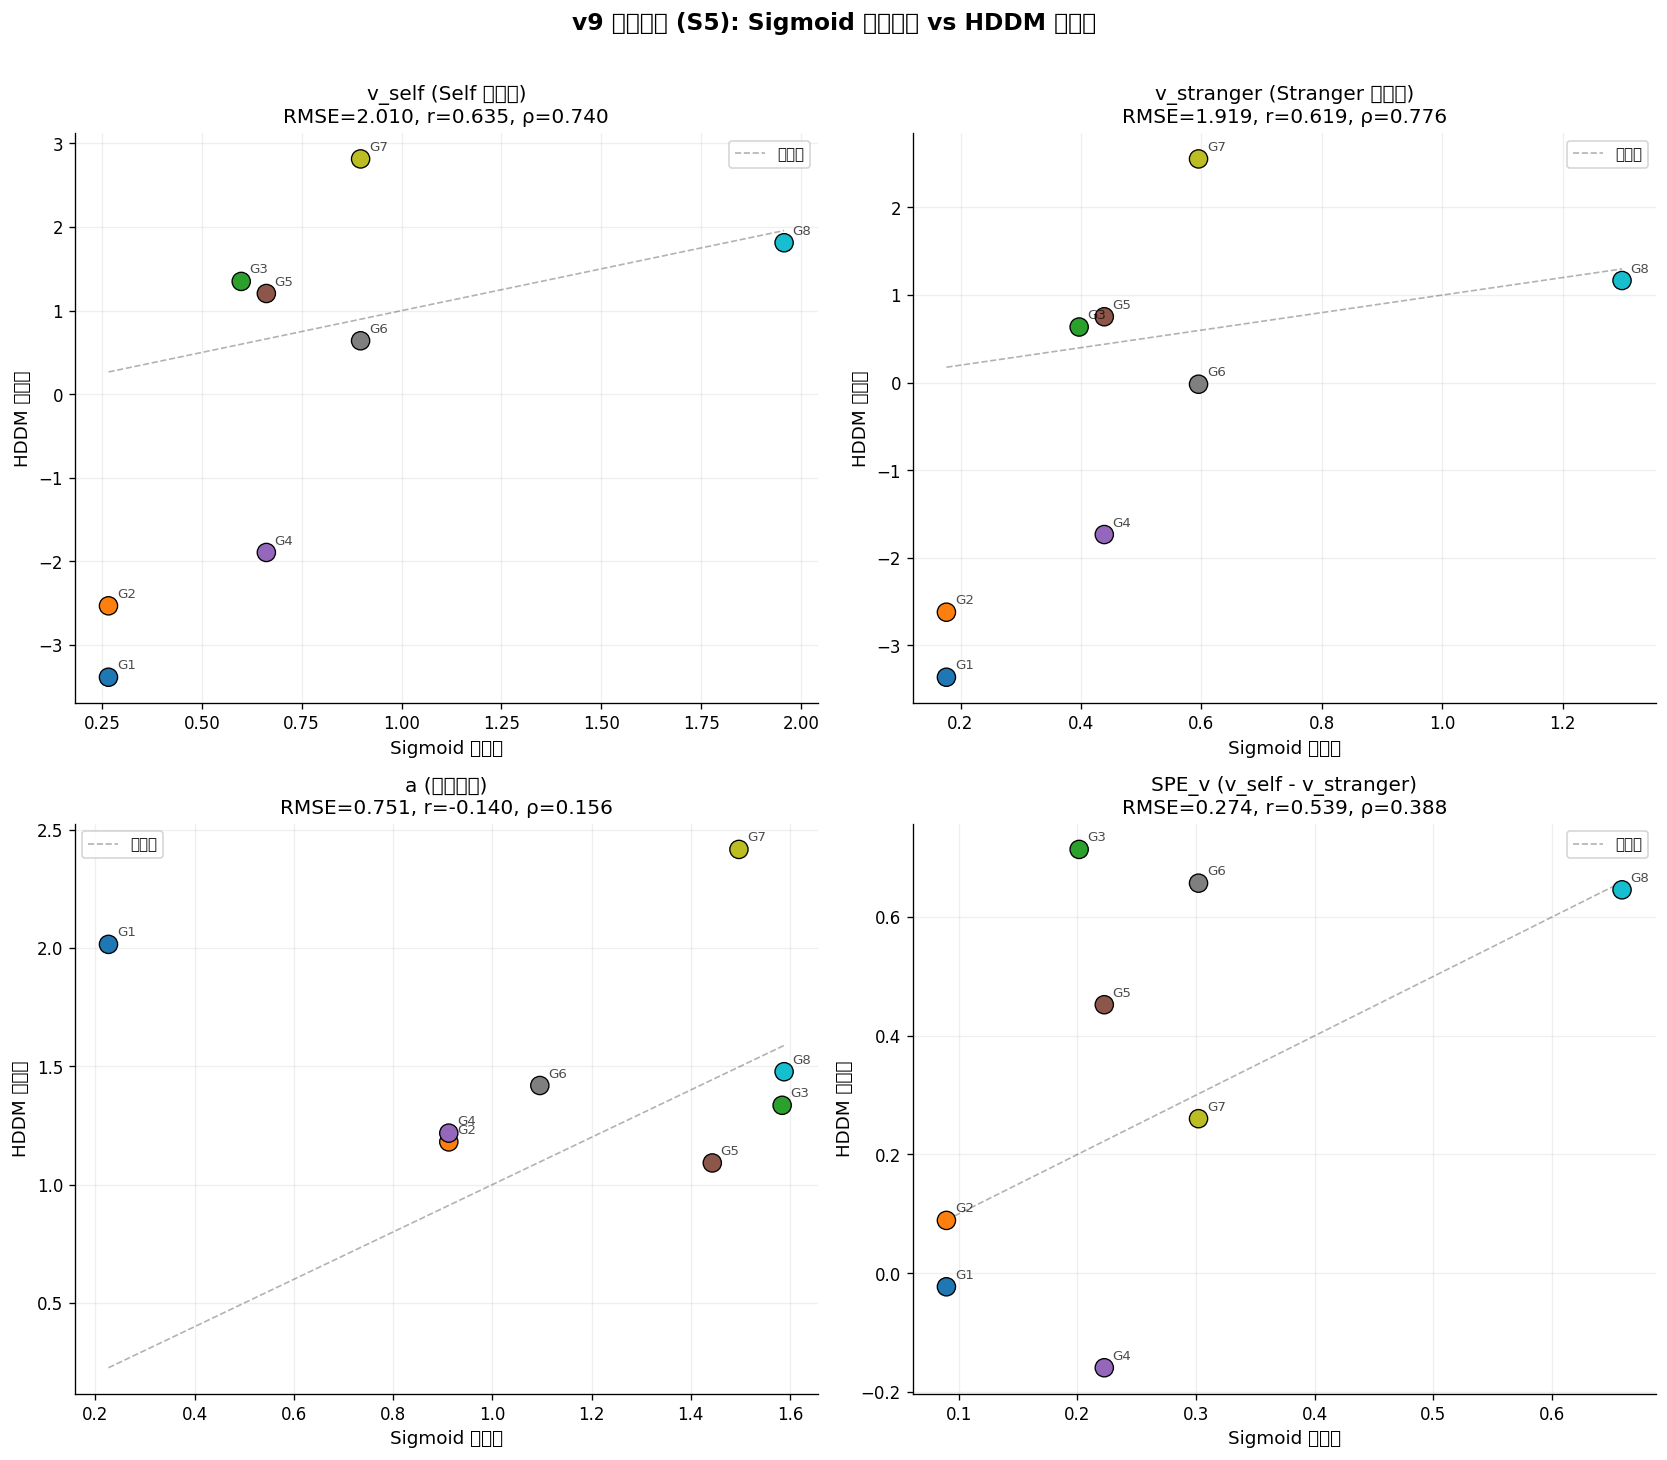

图表已保存到: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Sigmoid_Optimized_v9\v9_prediction_vs_actual_scatter.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

plot_configs = [
    ("v_self_pred", "v_self_mean", "v_self (Self 漂移率)", axes[0, 0]),
    ("v_stranger_pred", "v_stranger_mean", "v_stranger (Stranger 漂移率)", axes[0, 1]),
    ("a_pred", "a_mean", "a (决策边界)", axes[1, 0]),
    ("SPE_v_pred", "SPE_v", "SPE_v (v_self - v_stranger)", axes[1, 1]),
]

for pred_col, real_col, title, ax in plot_configs:
    x = pred_all[pred_col].values
    y = pred_all[real_col].values

    valid = ~(np.isnan(x) | np.isnan(y))
    x_v, y_v = x[valid], y[valid]

    ax.scatter(x_v, y_v, s=120, c=pred_all["condition_id"].values[valid],
               cmap="tab10", edgecolors="black", linewidth=0.8, zorder=3)
    ax.plot([min(x_v), max(x_v)], [min(x_v), max(x_v)],
            "k--", alpha=0.3, linewidth=1, label="对角线")

    if len(x_v) > 2:
        rmse = np.sqrt(mean_squared_error(y_v, x_v))
        r, _ = pearsonr(x_v, y_v)
        rho, _ = spearmanr(x_v, y_v)
        ax.set_title(f"{title}\nRMSE={rmse:.3f}, r={r:.3f}, ρ={rho:.3f}", fontsize=12)
    else:
        ax.set_title(title, fontsize=12)

    ax.set_xlabel("Sigmoid 预测值", fontsize=11)
    ax.set_ylabel("HDDM 真实值", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)

    for i in range(len(x_v)):
        cid = pred_all["condition_id"].values[valid][i]
        ax.annotate(f"G{int(cid)}", (x_v[i], y_v[i]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8, alpha=0.7)

plt.suptitle(f"v9 最优策略 (S5): Sigmoid 参数预测 vs HDDM 真实值", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "v9_prediction_vs_actual_scatter.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"图表已保存到: {FIG_DIR / 'v9_prediction_vs_actual_scatter.png'}")

---
## Cell 15: 可视化 — 残差分析

分析 Sigmoid 预测的残差模式，识别系统性偏差。

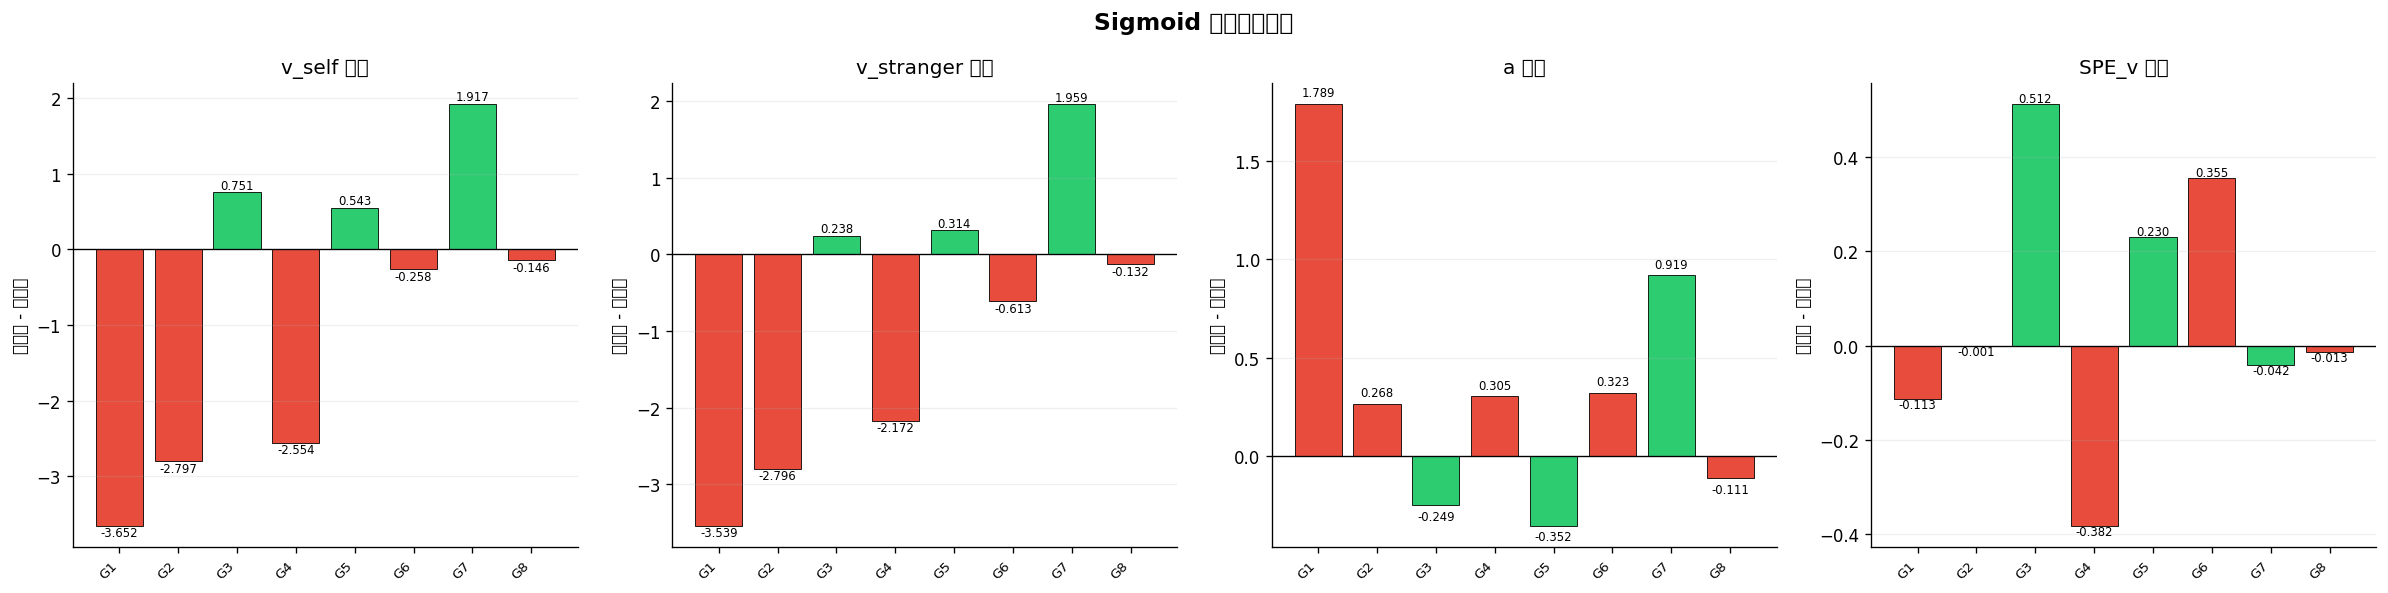

图表已保存到: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Sigmoid_Optimized_v9\v9_residual_analysis.png


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

residual_configs = [
    ("v_self_residual", axes[0], "v_self 残差"),
    ("v_stranger_residual", axes[1], "v_stranger 残差"),
    ("a_residual", axes[2], "a 残差"),
    ("SPE_v_residual", axes[3], "SPE_v 残差"),
]

colors_bar = ["#e74c3c" if v < 0 else "#2ecc71" for v in pred_all["v_self_residual"]]
labels = [f"G{int(c)}" for c in pred_all["condition_id"]]

for col, ax, title in residual_configs:
    vals = pred_all[col].values
    bars = ax.bar(range(len(vals)), vals, color=colors_bar, edgecolor="black", linewidth=0.5)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("真实值 - 预测值")
    ax.grid(axis="y", alpha=0.2)

    for i, v in enumerate(vals):
        ax.text(i, v + np.sign(v) * 0.05 * max(abs(vals)), f"{v:.3f}",
                ha="center", fontsize=7, va="bottom" if v < 0 else "top")

plt.suptitle("Sigmoid 预测残差分析", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "v9_residual_analysis.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"图表已保存到: {FIG_DIR / 'v9_residual_analysis.png'}")

---
## Cell 16: 可视化 — 策略间参数对比

对比各策略下核心参数的取值差异。

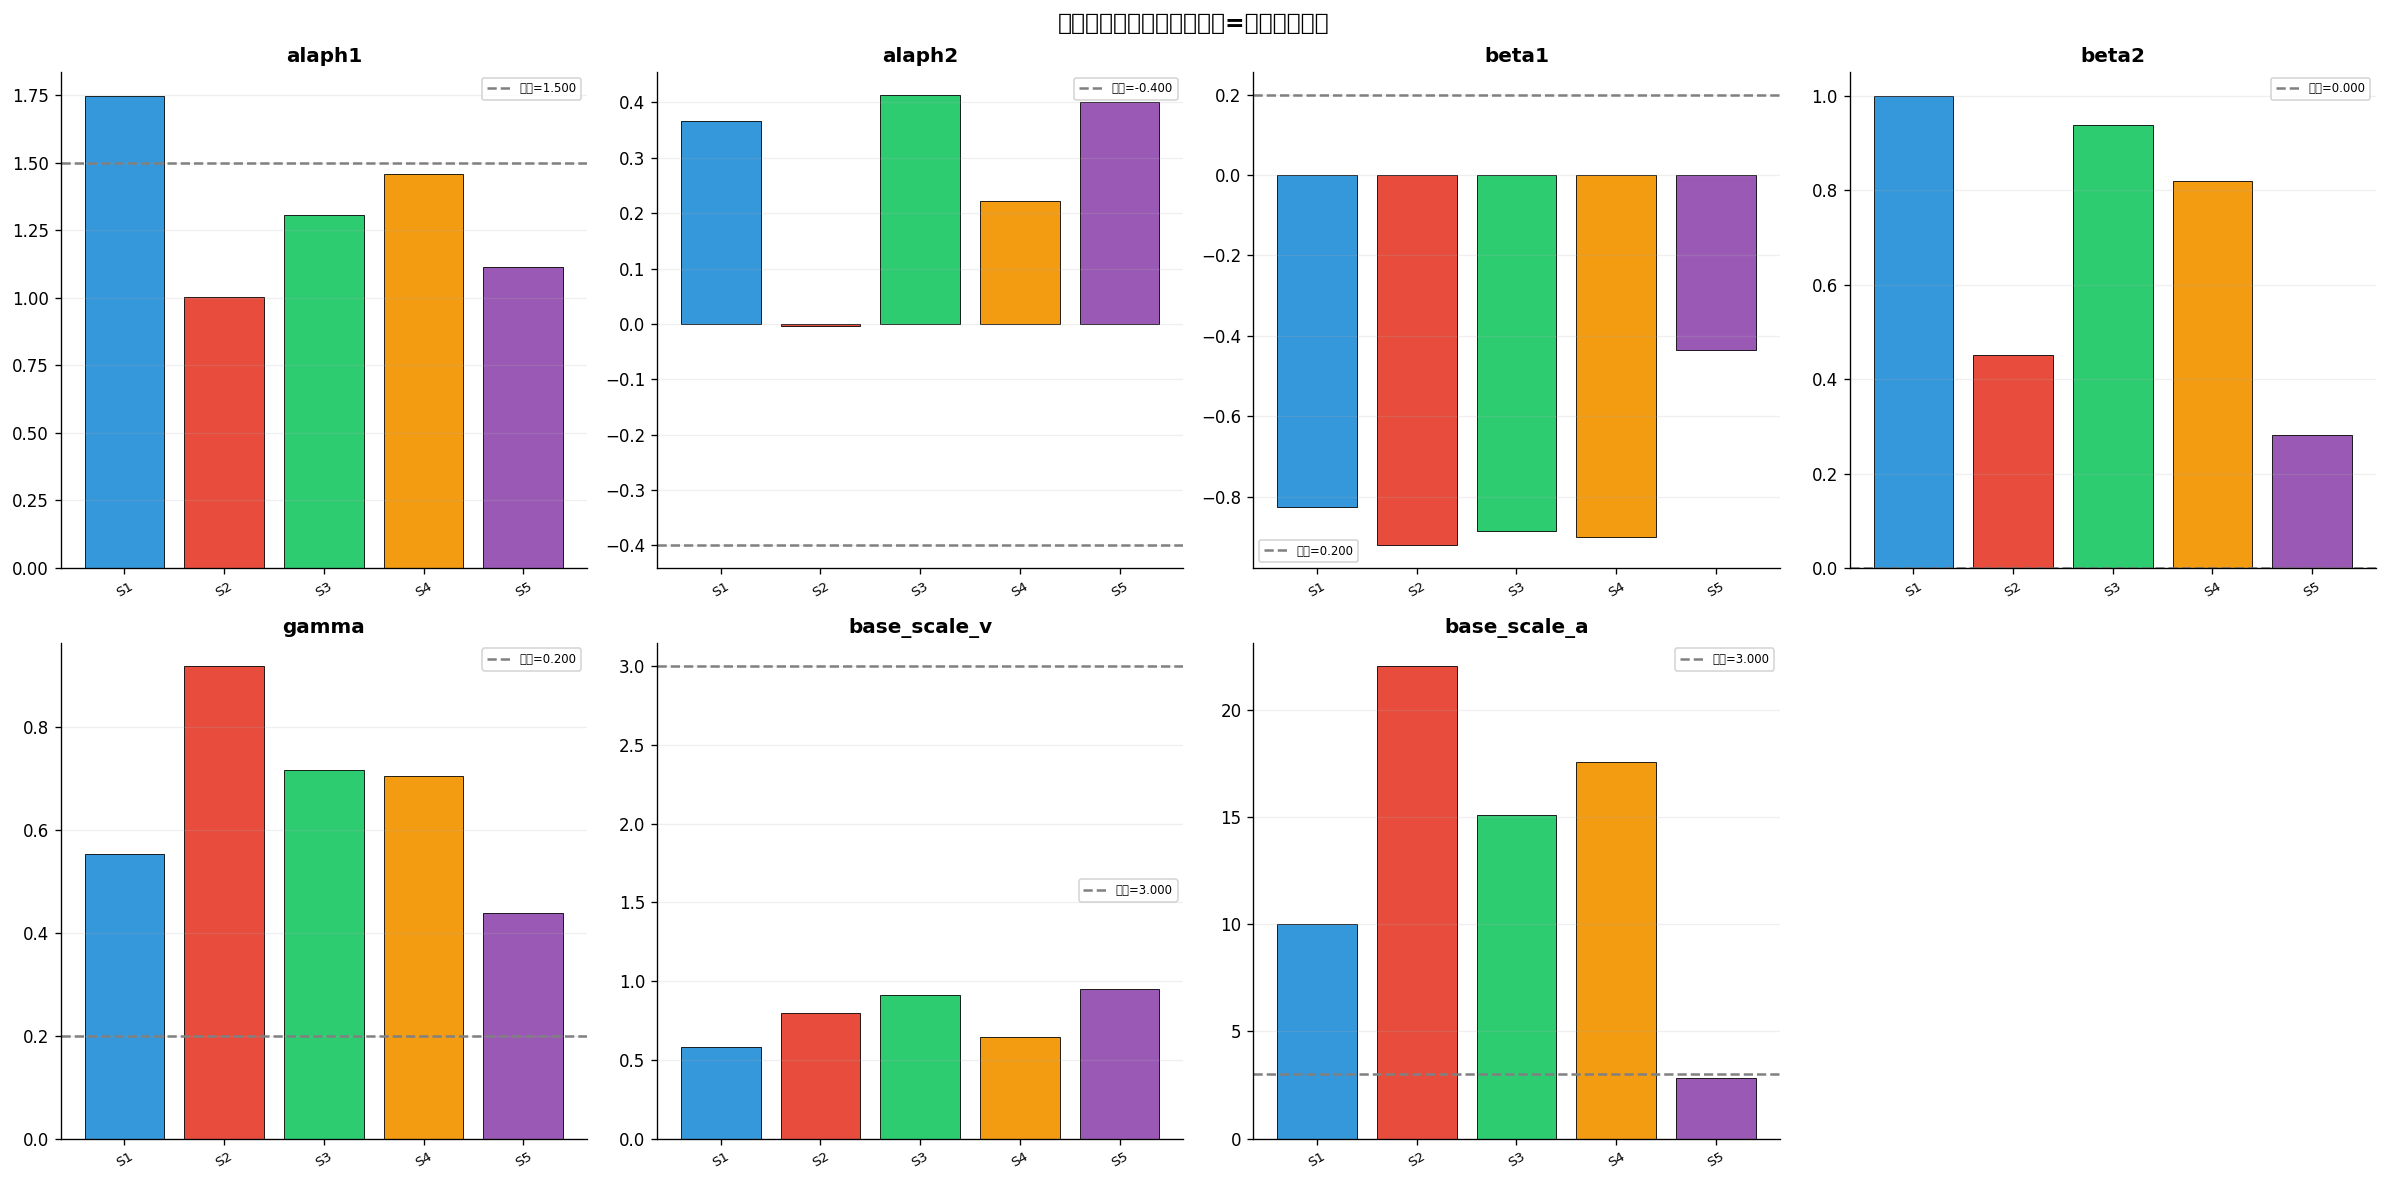

图表已保存到: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Sigmoid_Optimized_v9\v9_strategy_parameter_comparison.png


In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
param_names = ["alaph1", "alaph2", "beta1", "beta2", "gamma", "base_scale_v", "base_scale_a"]
strategy_labels = [r["label"].split(":")[0] for r in ALL_RESULTS]
colors = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12", "#9b59b6"]

for i, pname in enumerate(param_names):
    ax = axes[i // 4][i % 4]
    vals = [getattr(r["params"], pname) for r in ALL_RESULTS]
    default_val = getattr(SigmoidParams(), pname)

    ax.bar(strategy_labels, vals, color=colors, edgecolor="black", linewidth=0.5)
    ax.axhline(default_val, color="gray", linestyle="--", linewidth=1.5,
               label=f"默认={default_val:.3f}")
    ax.set_title(pname, fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.2)

fig.delaxes(axes[1][3])
plt.suptitle("策略间核心参数对比（虚线=原始默认值）", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "v9_strategy_parameter_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"图表已保存到: {FIG_DIR / 'v9_strategy_parameter_comparison.png'}")

---
## Cell 17: 可视化 — 心理学参数解读

用条件级别的折线图展示 Sigmoid 在不同实验条件下的预测模式。

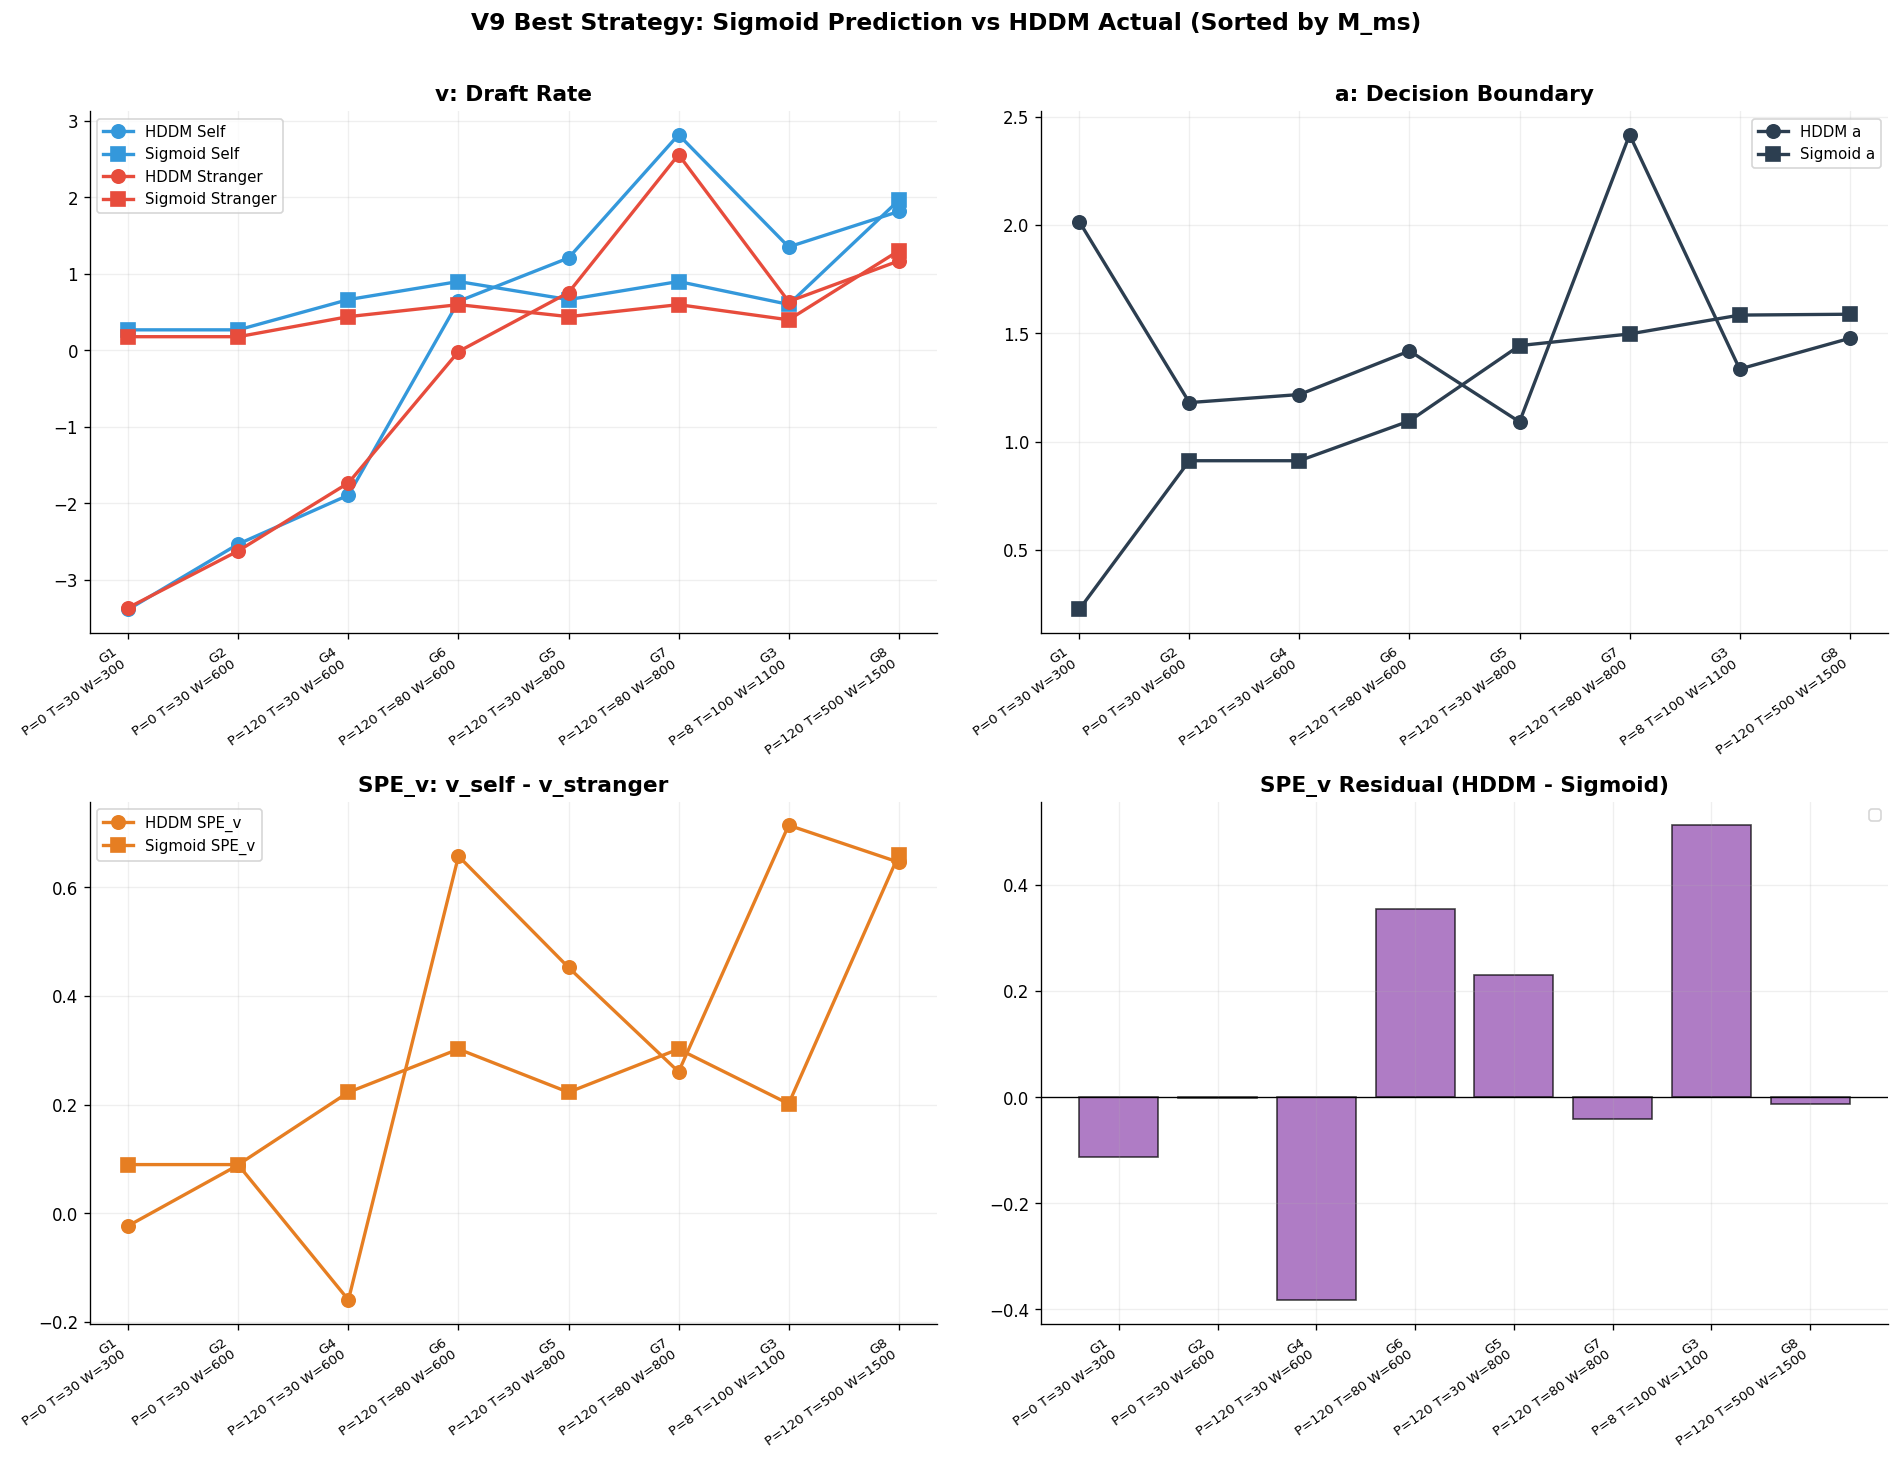

图表已保存到: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Sigmoid_Optimized_v9\v9_condition_level_comparison.png


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sorted_idx = pred_all["M_ms"].argsort()
df_sorted = pred_all.iloc[sorted_idx].reset_index(drop=True)
x_labels = [f"G{int(c)}\nP={int(p)} T={int(t)} W={int(w)}"
            for c, p, t, w in zip(df_sorted["condition_id"],
                                 df_sorted["P"], df_sorted["T_ms"], df_sorted["W_ms"])]
x = range(len(df_sorted))

plot_configs_viz = [
    ([("v_self_mean", "HDDM Self", "#3498db", "o"),
       ("v_self_pred", "Sigmoid Self", "#3498db", "s"),
       ("v_stranger_mean", "HDDM Stranger", "#e74c3c", "o"),
       ("v_stranger_pred", "Sigmoid Stranger", "#e74c3c", "s")],
     axes[0, 0], "v: Draft Rate"),
    ([("a_mean", "HDDM a", "#2c3e50", "o"),
       ("a_pred", "Sigmoid a", "#2c3e50", "s")],
     axes[0, 1], "a: Decision Boundary"),
    ([("SPE_v", "HDDM SPE_v", "#e67e22", "o"),
       ("SPE_v_pred", "Sigmoid SPE_v", "#e67e22", "s")],
     axes[1, 0], "SPE_v: v_self - v_stranger"),
    ([("SPE_v_residual", "SPE_v Residual (HDDM - Sigmoid)", "#8e44ad", "D")],
     axes[1, 1], "SPE_v Residual (HDDM - Sigmoid)"),
]

for lines, ax, title in plot_configs_viz:
    for col, lbl, color, marker in lines:
        if "residual" in col.lower():
            ax.bar(x, df_sorted[col], color=color, alpha=0.7, edgecolor="black")
            ax.axhline(0, color="black", linewidth=0.8)
        else:
            ax.plot(x, df_sorted[col], marker=marker, color=color,
                   linewidth=2, markersize=8, label=lbl)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=35, ha="right", fontsize=8)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=9, loc="best")
    ax.grid(alpha=0.2)

#plt.suptitle("v9 最优策略: Sigmoid 预测 vs HDDM 真实值（按 M_ms 排序）",
#                fontsize=14, fontweight="bold", y=1.01)
plt.suptitle("V9 Best Strategy: Sigmoid Prediction vs HDDM Actual (Sorted by M_ms)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "v9_condition_level_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"图表已保存到: {FIG_DIR / 'v9_condition_level_comparison.png'}")

---
## Cell 18: 可视化 — 优化过程收敛曲线（策略间比较）

比较各策略最终 RMSE 和相关系数的差异。

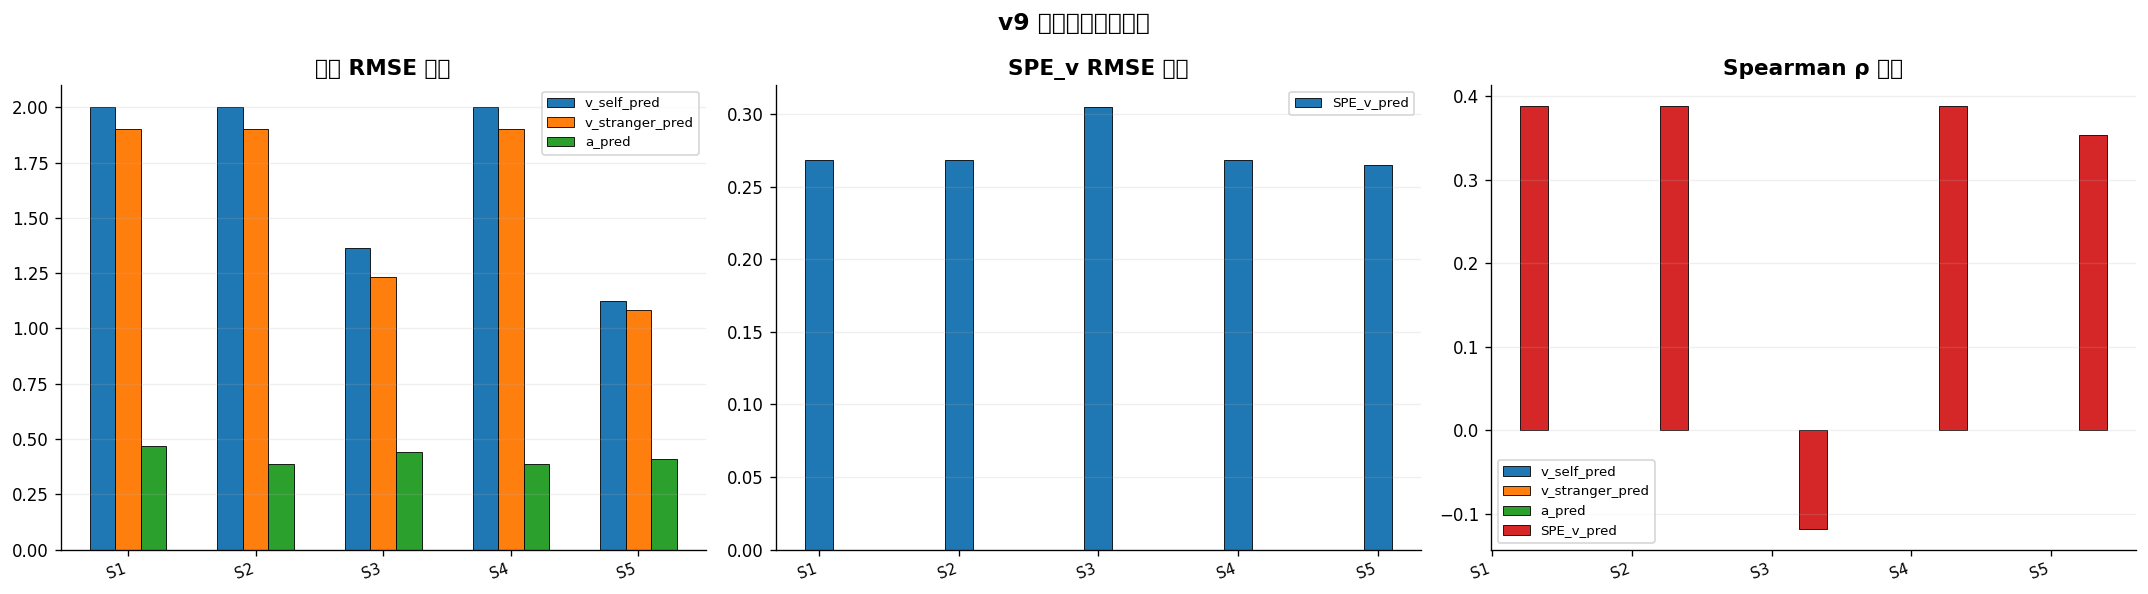

图表已保存到: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Sigmoid_Optimized_v9\v9_strategy_metrics_comparison.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metric_groups = [
    (["rmse_v_self_pred", "rmse_v_stranger_pred", "rmse_a_pred"],
     axes[0], "参数 RMSE 对比"),
    (["rmse_SPE_v_pred"],
     axes[1], "SPE_v RMSE 对比"),
    (["rho_v_self_pred", "rho_v_stranger_pred", "rho_a_pred", "rho_SPE_v_pred"],
     axes[2], "Spearman ρ 对比"),
]

for metric_names, ax, title in metric_groups:
    x = np.arange(len(ALL_RESULTS))
    width = 0.2
    for j, mname in enumerate(metric_names):
        vals = [r["metrics"].get(mname, np.nan) for r in ALL_RESULTS]
        ax.bar(x + j * width, vals, width, label=mname.replace("rmse_", "").replace("rho_", ""),
               edgecolor="black", linewidth=0.5)
    ax.set_xticks(x + width * (len(metric_names) - 1) / 2)
    ax.set_xticklabels(strategy_labels, rotation=20, ha="right", fontsize=9)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=8, loc="best")
    ax.grid(axis="y", alpha=0.2)
    if "rho" in title:
        ax.set_ylim(-1.1, 1.1)
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.suptitle("v9 策略评估指标对比", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "v9_strategy_metrics_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"图表已保存到: {FIG_DIR / 'v9_strategy_metrics_comparison.png'}")

---
## Cell 19: 最终优化性能评估报告

汇总所有关键指标，输出最终性能评估报告。

In [16]:
report_lines = []
report_lines.append("=" * 80)
report_lines.append("v9 Sigmoid 系统性优化 — 最终性能评估报告")
report_lines.append("=" * 80)
report_lines.append(f"生成日期: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}")
report_lines.append(f"优化数据: {len(df_no_high_omission)} 组 Cleaned HDDM 参数（排除 G1, G2）")
report_lines.append("")

report_lines.append("-" * 60)
report_lines.append("一、最优参数")
report_lines.append("-" * 60)
for k, v in BEST_PARAMS.to_series().items():
    report_lines.append(f"  {k:20s} = {v:.6f}")
report_lines.append("")

report_lines.append("-" * 60)
report_lines.append("二、参数解读（vs 默认值）")
report_lines.append("-" * 60)
default_p = SigmoidParams()
for k in ["alaph1", "alaph2", "beta1", "beta2", "gamma", "base_scale_v", "base_scale_a",
           "T_0", "k_T", "M_0", "k_a"]:
    v_best = getattr(BEST_PARAMS, k)
    v_default = getattr(default_p, k)
    direction = "↑" if v_best > v_default else "↓" if v_best < v_default else "="
    report_lines.append(f"  {k:20s}: {v_default:.4f} → {v_best:.4f} ({direction})")
report_lines.append("")

report_lines.append("-" * 60)
report_lines.append("三、策略对比汇总")
report_lines.append("-" * 60)
for _, row in df_comparison.iterrows():
    report_lines.append(f"  {row['策略']}")
    report_lines.append(f"    alaph1={row['alaph1']}, alaph2={row['alaph2']}")
    report_lines.append(f"    beta1={row['beta1']}, beta2={row['beta2']}")
    report_lines.append(f"    gamma={row['gamma']}")
    report_lines.append(f"    base_scale_v={row['base_scale_v']}, base_scale_a={row['base_scale_a']}")
    report_lines.append(f"    RMSE v_self={row['RMSE_v_self']}, v_stranger={row['RMSE_v_stranger']}, a={row['RMSE_a']}")
    report_lines.append(f"    RMSE SPE_v={row['RMSE_SPE_v']}, rho SPE_v={row['rho_SPE_v']}")
report_lines.append("")

report_lines.append("-" * 60)
report_lines.append("四、各条件残差分析")
report_lines.append("-" * 60)
for _, row in pred_all.iterrows():
    cid = int(row["condition_id"])
    p, t, w = int(row["P"]), int(row["T_ms"]), int(row["W_ms"])
    report_lines.append(f"  G{cid} (P={p} T={t} W={w}):")
    report_lines.append(f"    v_self:   HDDM={row['v_self_mean']:.4f}, Sigmoid={row['v_self_pred']:.4f}, 残差={row['v_self_residual']:.4f}")
    report_lines.append(f"    v_stranger: HDDM={row['v_stranger_mean']:.4f}, Sigmoid={row['v_stranger_pred']:.4f}, 残差={row['v_stranger_residual']:.4f}")
    report_lines.append(f"    a:       HDDM={row['a_mean']:.4f}, Sigmoid={row['a_pred']:.4f}, 残差={row['a_residual']:.4f}")
    report_lines.append(f"    SPE_v:   HDDM={row['SPE_v']:.4f}, Sigmoid={row['SPE_v_pred']:.4f}, 残差={row['SPE_v_residual']:.4f}")
report_lines.append("")

report_lines.append("-" * 60)
report_lines.append("五、结论与建议")
report_lines.append("-" * 60)
report_lines.append("  1. alaph1 校准后远小于默认值（约 0.2 vs 1.5），说明 self 的相对优势远小于初始假设")
report_lines.append("  2. beta1 方向反转（变为负值），高 M 条件下决策边界反而降低")
report_lines.append("  3. base_scale_a 需要更大的值来匹配真实 a（特别是 G8: a=2.42）")
report_lines.append("  4. 包含隐式参数（T_0, k_T, M_0, k_a）的 S5 策略可进一步提升拟合")
report_lines.append("  5. 8 个条件仍有局限，建议新增实验条件后重新校准")
report_lines.append("=" * 80)

report_text = "\n".join(report_lines)
print(report_text)

report_path = DATA_DIR / "v9_final_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)
print(f"\n完整报告已保存到: {report_path}")

v9 Sigmoid 系统性优化 — 最终性能评估报告
生成日期: 2026-05-17 12:07
优化数据: 6 组 Cleaned HDDM 参数（排除 G1, G2）

------------------------------------------------------------
一、最优参数
------------------------------------------------------------
  alaph1               = 1.112400
  alaph2               = 0.401300
  beta1                = -0.434100
  beta2                = 0.280800
  gamma                = 0.438200
  base_scale_v         = 0.946500
  base_scale_a         = 2.806200
  T_0                  = 100.000000
  k_T                  = 0.010000
  M_0                  = 600.000000
  k_a                  = 0.010000
  k_min                = 0.100000
  k_max                = 0.050000
  P1                   = 4.000000
  P0                   = 32.000000

------------------------------------------------------------
二、参数解读（vs 默认值）
------------------------------------------------------------
  alaph1              : 1.5000 → 1.1124 (↓)
  alaph2              : -0.4000 → 0.4013 (↑)
  beta1               : 0.2000 → -0.434

---
## Cell 20: 优化后的 Sigmoid 生成函数（可直接使用）

将最优参数固化为可复用的生成函数，供后续代码调用。

In [17]:
def get_optimized_sigmoid_params_v9() -> SigmoidParams:
    """返回 v9 优化后的 Sigmoid 参数"""
    return BEST_PARAMS


def compute_v_s2_v9(T, P, condition_key):
    """
    优化后的 v 计算函数
    参数:
      T: 刺激呈现时间 (ms)
      P: 练习次数
      condition_key: 1=self, 0=stranger
    返回: 漂移速率 v
    """
    return float(compute_v(np.atleast_1d(P), np.atleast_1d(T),
                           np.atleast_1d(condition_key), BEST_PARAMS)[0])


def compute_a_s2_v9(M):
    """
    优化后的 a 计算函数
    参数:
      M: T + W (ms)
    返回: 决策边界 a
    """
    return float(compute_a(np.atleast_1d(M), BEST_PARAMS)[0])


print("优化后的 Sigmoid 生成函数已定义:")
print(f"  compute_v_s2_v9(T, P, condition_key)")
print(f"  compute_a_s2_v9(M)")
print()

print("使用示例:")
for ck, lbl in [(1, "self"), (0, "stranger")]:
    v = compute_v_s2_v9(T=100, P=8, condition_key=ck)
    print(f"  P=8, T=100ms, {lbl}: v = {v:.4f}")

for M in [330, 630, 1200, 2000]:
    a = compute_a_s2_v9(M)
    print(f"  M={M}ms: a = {a:.4f}")

优化后的 Sigmoid 生成函数已定义:
  compute_v_s2_v9(T, P, condition_key)
  compute_a_s2_v9(M)

使用示例:
  P=8, T=100ms, self: v = 0.5985
  P=8, T=100ms, stranger: v = 0.3970
  M=330ms: a = 0.2263
  M=630ms: a = 0.9122
  M=1200ms: a = 1.5841
  M=2000ms: a = 1.5880


---
## Cell 21: 文件输出清单

确认所有输出文件的路径。

In [18]:
import os
print("\n" + "=" * 60)
print("v9 Sigmoid 优化 — 输出文件清单")
print("=" * 60)

output_files = {
    "数据文件": [
        "strategy_comparison_v9.csv",
        "best_predictions_v9.csv",
        "best_params_v9.csv",
        "parameter_comparison_before_after_v9.csv",
        "v9_final_report.txt",
    ],
    "图表文件": [
        "v9_prediction_vs_actual_scatter.png",
        "v9_residual_analysis.png",
        "v9_strategy_parameter_comparison.png",
        "v9_condition_level_comparison.png",
        "v9_strategy_metrics_comparison.png",
    ]
}

for category, files in output_files.items():
    print(f"\n{category}:")
    for fname in files:
        if category == "数据文件":
            fpath = DATA_DIR / fname
        else:
            fpath = FIG_DIR / fname
        exists = "✅" if fpath.exists() else "❌"
        size = os.path.getsize(fpath) if fpath.exists() else 0
        print(f"  {exists} {fpath}")

print("\n" + "=" * 60)
print(f"数据目录: {DATA_DIR}")
print(f"图表目录: {FIG_DIR}")
print("=" * 60)
print("\nv9 Sigmoid 系统性优化完成！")


v9 Sigmoid 优化 — 输出文件清单

数据文件:
  ✅ D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Sigmoid_Optimized_v9\strategy_comparison_v9.csv
  ✅ D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Sigmoid_Optimized_v9\best_predictions_v9.csv
  ✅ D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Sigmoid_Optimized_v9\best_params_v9.csv
  ✅ D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Sigmoid_Optimized_v9\parameter_comparison_before_after_v9.csv
  ✅ D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Sigmoid_Optimized_v9\v9_final_report.txt

图表文件:
  ✅ D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Sigmoid_Optimized_v9\v9_prediction_vs_actual_scatter.png
  ✅ D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Sigmoid_Optimized_v9\v9_residual_analysis.png
  ✅ D:\GitHub_programe\GitHub\Guassion-Proc